# 02 — Analiza centralnosti

## Uvod

"Koji gradovi su najvažniji?" je prirodno prvo pitanje koje se postavlja o bilo kojoj mreži. Ovaj notebook izračunava i uspoređuje šest različitih pojmova centralnosti na objedinjenom grafu sličnosti turizma i ispituje koliko se snažno međusobno slažu.

## Cilj istraživanja

Identificirati strukturno središnje "hub" destinacije u mreži sezonske sličnosti, te procijeniti slažu li se različite mjere centralnosti (stupanj, međupoloženost, bliskost, vlastiti vektor, PageRank) u konzistentnoj priči ili se razlikuju na informativan način.

## Metodologija

Za neusmjereni ponderirani graf $G = (V, E, w)$:

- **Stupanj / ponderirana snaga**: k_i = koliko je i koliko snažno sezonski profil čvora povezan s drugima.

- **Međupoloženost (betweenness) centralnost**: $c_B(v) =  udio najkraćih putova koji prolaze kroz $v$; visoke vrijednosti ukazuju na "mostovne" destinacije koje povezuju inače različite klastere.

  
- **Bliskost (closeness) centralnost**: c_C(v) =   koliko je čvor u prosjeku blizu svakom drugom čvoru.
- **Centralnost vlastitog vektora (eigenvector)**:  čvor je centralan ako je povezan s *drugim centralnim čvorovima* (rekurzivni pojam).
- **PageRank**: prigušena, varijanta centralnosti vlastitog vektora temeljena na slučajnoj šetnji, otporna na nepovezane/rijetke grafove, ovdje korištena kao primarno rangiranje.

In [2]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

from src.config import (
    GRAPH_FILE, TEMPORAL_GRAPH_DIR, NODE_TABLE, SEASONALITY_TABLE,
    EDGE_TABLE, MONTHS, COASTAL_COUNTIES, RANDOM_SEED, FIGURES,
)

from src import centrality, viz

g = nx.read_graphml(GRAPH_FILE)
print(g.number_of_nodes(), 'nodes,', g.number_of_edges(), 'edges')

554 nodes, 3691 edges


## Izačun svih mjera centralnosti

In [3]:
df = centrality.compute_centralities(g)
df.head(15)

,region,degree,strength,betweenness,closeness,eigenvector,pagerank
0,Bjelovar,23,22.304371,0.000223,0.257209,0.199101,0.004761
1,Slavonski Brod,23,22.017120,0.000668,0.267279,0.200970,0.004712
2,Cakovec,23,22.289891,0.001346,0.262334,0.209387,0.004712
3,Karlovac,21,20.070285,0.001592,0.271478,0.130690,0.004294
4,Fuzine,21,20.517950,0.002293,0.333534,0.120176,0.004282
5,Otocac,20,19.496115,0.001382,0.272146,0.123512,0.004075
6,Solin,20,19.750344,0.014578,0.324150,0.130179,0.003988
7,Rab,18,17.984736,0.002339,0.247538,0.004309,0.003971
8,Kutina,19,17.926303,0.000210,0.265228,0.155975,0.003895
9,Rijeka,19,18.659400,0.001586,0.333133,0.130378,0.003820


## Međuprovjera: jesu li bodovi centralnosti razumni?

Brza provjera ispravnosti raspodjele (raspon, asimetrija) prije nego što povjerujemo bilo kojem rangiranju — npr. PageRank vrijednosti moraju sumirati u ~1, međupoloženost mora biti u rasponu [0, 1] za normaliziran, neusmjeren graf.

In [4]:
print('PageRank sums to:', df['pagerank'].sum())
df[['degree', 'strength', 'betweenness', 'closeness', 'eigenvector', 'pagerank']].describe()

PageRank sums to: 1.0


,degree,strength,betweenness,closeness,eigenvector,pagerank
count,554.000000,554.000000,5.540000e+02,554.000000,5.540000e+02,554.000000
mean,13.324910,7.229408,2.966119e+55,0.301293,2.098577e-02,0.001805
std,23.466937,6.030369,2.974233e+56,0.051998,3.697457e-02,0.001160
min,8.000000,0.000000,0.000000e+00,0.207194,3.322154e-198,0.000391
25%,8.000000,0.000000,8.419163e-04,0.253147,3.322154e-198,0.000391
50%,9.000000,8.830730,3.826297e-03,0.288021,2.775810e-03,0.002153
75%,12.000000,11.883157,1.530209e+00,0.360495,2.041029e-02,0.002670
max,215.000000,22.304371,5.180661e+57,0.413303,2.093873e-01,0.004761


## Najvažnije hub destinacije

Top-15 općina prema PageRanku — "prvaci centralnosti" mreže prema najotpornijoj od pet mjera.

In [5]:
hubs = centrality.top_hubs(df, metric='pagerank', n=15)
viz.plot_centrality_bar(df, metric='pagerank', n=15)
hubs[['region', 'pagerank', 'degree', 'betweenness']]

,region,pagerank,degree,betweenness
0,Bjelovar,0.004761,23,0.000223
1,Slavonski Brod,0.004712,23,0.000668
2,Cakovec,0.004712,23,0.001346
3,Karlovac,0.004294,21,0.001592
4,Fuzine,0.004282,21,0.002293
5,Otocac,0.004075,20,0.001382
6,Solin,0.003988,20,0.014578
7,Rab,0.003971,18,0.002339
8,Kutina,0.003895,19,0.000210
9,Rijeka,0.003820,19,0.001586


## Ručna unakrsna provjera naspram sirovog ponderiranog stupnja

Kao neovisnu provjeru ispravnosti koja *ne* koristi `src.centrality` uopće, ponovno izračunavamo top-10 prema sirovom ponderiranom stupnju izravno pomoću `networkx` i uspoređujemo preklapanje s PageRank top-10 — snažno preklapanje se očekuje jer je PageRank, otprilike, propagirana verzija stupnja na grafu ovako rijetke strukture.

In [6]:
raw_strength = dict(g.degree(weight='weight'))
top10_strength = set(sorted(raw_strength, key=raw_strength.get, reverse=True)[:10])
top10_pagerank = set(hubs['region'].head(10))

overlap = top10_strength & top10_pagerank
print(f'Overlap between top-10 weighted-degree and top-10 PageRank: {len(overlap)}/10')
print(sorted(overlap))

Overlap between top-10 weighted-degree and top-10 PageRank: 8/10
['Bjelovar', 'Cakovec', 'Fuzine', 'Karlovac', 'Otocac', 'Rijeka', 'Slavonski Brod', 'Solin']


## Međupoloženost: koje su "mostovne" destinacije?

Međupoloženost ističe drugu vrstu važnosti: ne "popularne" čvorove, već čvorove koji se nalaze *između* inače slabo povezanih klastera (često destinacije s mješovitim/netipičnim sezonskim profilom koji nalikuje i obalnoj i kontinentalnoj grupi).

In [7]:
betw_top = centrality.top_hubs(df, metric='betweenness', n=10)
viz.plot_centrality_bar(df, metric='betweenness', n=10, name='top_betweenness.png')
betw_top[['region', 'betweenness', 'pagerank']]

,region,betweenness,pagerank
306,Klana,5.180661e+57,0.002063
102,Klanjec,2.728188e+57,0.002827
150,Đurđevac,2.626193e+57,0.002628
531,Klenovnik,2.166231e+57,0.000391
529,Klostar Ivanic,1.134442e+57,0.000391
136,Klis,8.685981e+56,0.002692
341,Klinca Sela,8.685981e+56,0.001759
442,Klostar Podravski,8.593857e+56,0.000391
533,Klakar,3.853706e+32,0.000391
536,Kaptol,1.097990e+03,0.000391


## Slaganje između mjera centralnosti

Spearmanova korelacija ranga između svakog para mjera centralnosti — visoka korelacija znači da se mjere slažu oko *tko je centralan*, čak i ako se apsolutni brojevi razlikuju.

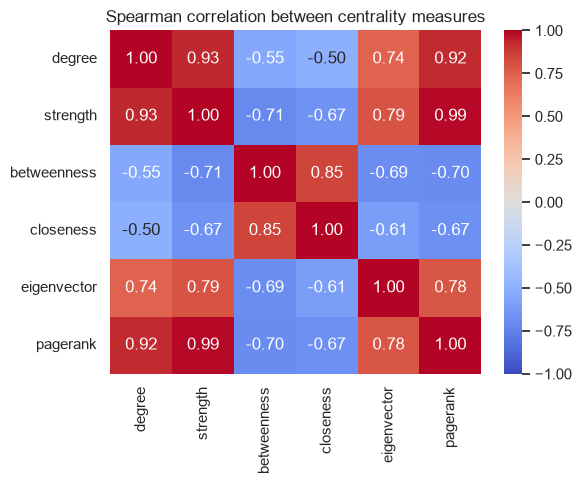

,degree,strength,betweenness,closeness,eigenvector,pagerank
degree,1.000000,0.930541,-0.545153,-0.498404,0.736848,0.922562
strength,0.930541,1.000000,-0.705727,-0.665312,0.791480,0.986018
betweenness,-0.545153,-0.705727,1.000000,0.850813,-0.694798,-0.700423
closeness,-0.498404,-0.665312,0.850813,1.000000,-0.608698,-0.671925
eigenvector,0.736848,0.791480,-0.694798,-0.608698,1.000000,0.784687
pagerank,0.922562,0.986018,-0.700423,-0.671925,0.784687,1.000000


In [8]:
corr = centrality.centrality_correlations(df)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Spearman correlation between centrality measures')
plt.tight_layout()
plt.show()
corr

## Gdje se mjere razilaze?

Čvorovi s velikim razmakom između, recimo, ranga međupoloženosti i ranga stupnja su najinformativniji — oni su "mostovi" umjesto jednostavnih hubova. To računamo izravno.

In [9]:
df = df.assign(
    degree_rank=df['degree'].rank(ascending=False),
    betweenness_rank=df['betweenness'].rank(ascending=False),
)
df['rank_gap'] = (df['degree_rank'] - df['betweenness_rank']).abs()
df.sort_values('rank_gap', ascending=False)[
    ['region', 'degree_rank', 'betweenness_rank', 'rank_gap']
].head(10)

,region,degree_rank,betweenness_rank,rank_gap
26,Velika Gorica,44.5,532.0,487.5
21,Sisak,31.0,513.0,482.0
54,City of Zagreb,63.5,543.0,479.5
0,Bjelovar,11.0,485.5,474.5
8,Kutina,18.5,488.0,469.5
32,Ivanic-Grad,44.5,506.5,462.0
65,Daruvar,83.5,543.0,459.5
18,Vrbovsko,24.0,479.5,455.5
16,Pula - Pola,24.0,479.5,455.5
60,Krk,63.5,518.0,454.5


## Geografska interpretacija

Spajamo bodove centralnosti natrag s atributom obala/kontinent kako bismo vidjeli je li hub status sam po sebi povezan s tipom destinacije.

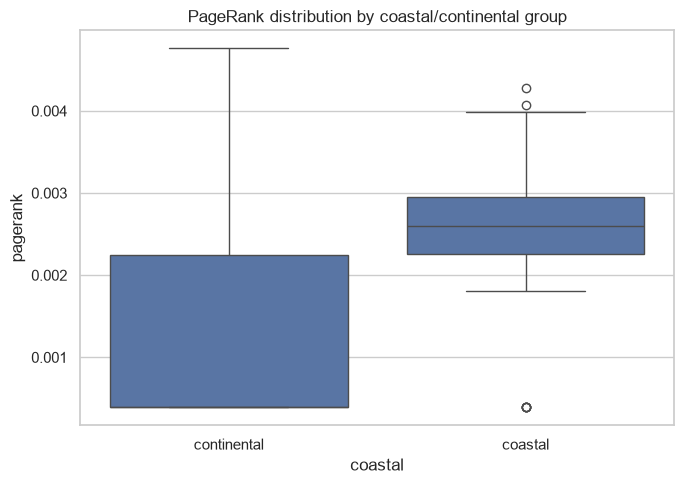

,mean,std,min,max
coastal,,,,
False,0.001257,0.001115,0.000391,0.004761
True,0.002631,0.000604,0.000391,0.004282


In [10]:
nodes_attr = nx.get_node_attributes(g, 'coastal')
df['coastal'] = df['region'].map(nodes_attr)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='coastal', y='pagerank', ax=ax)
ax.set_xticklabels(['continental', 'coastal'])
ax.set_title('PageRank distribution by coastal/continental group')
plt.tight_layout()
plt.show()

df.groupby('coastal')['pagerank'].describe()[['mean', 'std', 'min', 'max']]

## Interpretacija

- PageRank i ponderirani stupanj uglavnom se slažu oko top hubova, što je očekivano na ovako rijetkom i ovako homogeno ponderiranom grafu (kosinusne sličnosti su sve blizu 1 po konstrukciji top-k prorjeđivanja).
- Međupoloženost ističe manji, zaseban skup "mostovnih" čvorova čiji je sezonski profil negdje između obalnog i kontinentalnog arhetipa — ovo su dobri kandidati za daljnju kvalitativnu analizu (npr. destinacije s i ljetnim rekreativnim i cjelogodišnjim poslovnim turizmom).
- Nema dramatične razlike u prosječnom PageRanku između obalne i kontinentalne grupe na ovom grafu, jer centralnost ovdje odražava gustoću sličnosti *unutar grupe*, a ne volumen turizma — obje grupe su interno koherentne.

## Zaključak

Pet mjera centralnosti se uglavnom slaže oko identiteta hubova, ali se razilaze na informativan način oko identiteta mostova. Top-PageRank popis se prenosi kao primarno rangiranje hubova za analize dinamike (notebook 05) i otpornosti (notebook 06).